<a href="https://colab.research.google.com/github/TanVi3001/Leakage_Data/blob/main/Mnist_leakageData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bài toán 1: Data Leakage trên MNIST bằng PyTorch

## TN này chia thành 2 model
- Dữ liệu test hoàn toàn không tham gia training.(MNIST CLEAN)

- Cố tình cho một phần dữ liệu test xuất hiện trong training.(Mnist LEAKAGE)

--> Cuối cùng so sánh kết quả

### Ta có:
- 60.000 ảnh(train).
- 10.000 ảnh(test).


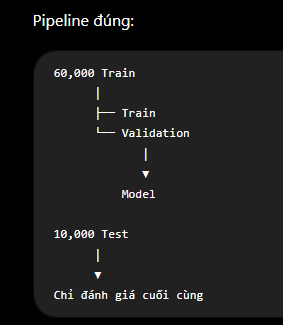

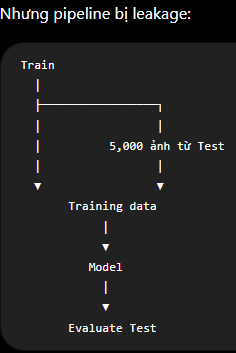

## --> **Tức là model đã được học trên chính một phần dữ liệu dùng để kiểm tra.**

### Kết quả là: Accuracy ban đầu có thể là đẹp nhưng không còn phản ánh khả năng generalization thật mà vốn dĩ model dự doán được

## Load MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset
from torchvision import datasets, transforms

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


## Transform:

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

## Load dataset MNIST:

In [3]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 159kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.46MB/s]

60000
10000


## Trường hợp tạo Train / Validation đúng

### Không dùng test để validation.

In [4]:
generator = torch.Generator().manual_seed(42)

train_set, val_set = torch.utils.data.random_split(
    train_dataset,
    [54000, 6000],
    generator=generator
)

### Tạo DataLoader:

In [5]:
train_loader = DataLoader(
    train_set,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

## CNN cho MNIST

In [6]:
class MNISTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                64 * 7 * 7,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

## Hàm train

In [7]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    total = 0
    correct = 0
    total_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        total_loss / total,
        correct / total
    )

## Evaluation(Đánh giá)

In [8]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    total = 0
    correct = 0
    total_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        total_loss += (
            loss.item()
            * images.size(0)
        )

    return (
        total_loss / total,
        correct / total
    )

## Thí nghiệm MNIST CLEAN

In [9]:
model_clean = MNISTCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_clean.parameters(),
    lr=0.001
)

### Train

In [10]:
for epoch in range(5):

    train_loss, train_acc = train_one_epoch(
        model_clean,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = evaluate(
        model_clean,
        val_loader,
        criterion
    )

    print(
        f"Epoch {epoch+1} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1 | Train Acc: 0.9379 | Val Acc: 0.9818
Epoch 2 | Train Acc: 0.9809 | Val Acc: 0.9862
Epoch 3 | Train Acc: 0.9863 | Val Acc: 0.9872
Epoch 4 | Train Acc: 0.9886 | Val Acc: 0.9900
Epoch 5 | Train Acc: 0.9908 | Val Acc: 0.9900


## Sau khi train xong mới test:

In [11]:
test_loss, test_acc = evaluate(
    model_clean,
    test_loader,
    criterion
)

print(
    "Clean Test Accuracy:",
    test_acc
)

Clean Test Accuracy: 0.9928


## Demo Data Leakage
### Lấy ví dụ 5000 ảnh từ test và đưa ảnh test này vào để model training

In [12]:
leaked_test = Subset(
    test_dataset,
    list(range(5000))
)

### Training dataset sai:

In [13]:
leaked_train_set = ConcatDataset([
    train_set,
    leaked_test
])

### Loader:

In [14]:
leaked_train_loader = DataLoader(
    leaked_train_set,
    batch_size=128,
    shuffle=True
)

## Pipeline bây giờ:
### 54.000 Train + 5.000 Test = 59.000 Training samples

In [15]:
model_leak = MNISTCNN().to(device)

optimizer = optim.Adam(
    model_leak.parameters(),
    lr=0.001
)

In [17]:
for epoch in range(5):

    loss, acc = train_one_epoch(
        model_leak,
        leaked_train_loader,
        optimizer,
        criterion
    )

    print(
        f"Epoch {epoch+1} | "
        f"Train Acc: {acc:.4f}"
    )

Epoch 1 | Train Acc: 0.9359
Epoch 2 | Train Acc: 0.9793
Epoch 3 | Train Acc: 0.9859
Epoch 4 | Train Acc: 0.9887
Epoch 5 | Train Acc: 0.9898


## Và đánh giá trên test:


In [18]:
test_loss, leaked_test_acc = evaluate(
    model_leak,
    test_loader,
    criterion
)

print(
    "Leaked Test Accuracy:",
    leaked_test_acc
)

Leaked Test Accuracy: 0.9964


# Kết luận:
## Clean Test Accuracy: 0.9928 (Cho trường hợp không lấy dữ liệu test cho model train)
## Leaked Test Accuracy: 0.9964 (Cho trường hợp lấy dữ liệu test cho model train)

## Cụ thể là:

- Trong MNIST, Data Leakage được demo bằng cách cố tình đưa một phần dữ liệu test vào training.

- Điểm quan trọng không phải chỉ là accuracy tăng.

### Mà ngoài ra quan trọng hơn là: Model đã nhìn thấy test -> Test không còn độc lập -> Tức lúc này Accuracy không còn phản ánh đúng thực tế mà model đã được train